In [1]:
import os
import sys
from dotenv import find_dotenv
sys.path.append(os.path.dirname(find_dotenv()))
import glob
from pathlib import Path
import multiprocessing

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import astropy.units as u
import astropy.constants as const
import arby
import tqdm
import dill as pickle
import emcee
import dynesty
import dynesty.plotting
import corner
from multiprocess.pool import Pool, ThreadPool
# from multiprocessing import ThreadPool

import dill
import dynesty.utils
dynesty.utils.pickle_module = dill

import isidora.waveform
import isidora.plotting
import isidora.training

/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
rng = np.random.default_rng(329143094)

In [3]:
downsampled_time_data = np.load('data/toy-mcmc/downsampled_time.npz')
downsampled_time, downsample_mask = downsampled_time_data['downsampled_time'], downsampled_time_data['mask']

downsampled_time *= u.s

In [4]:
# Have to get this just because loaded 'all-times' ROQ waveform function
# has this as a prefactor.

with open('data/toy-mcmc/injected_wf_params.pkl', 'rb') as f:
    injected_wf_params = pickle.load(f)

print(injected_wf_params)

wf_amp = injected_wf_params['wf_amp_factor']

{'q': 1, 'init_phi': 3.141592653589793, 'initial_freq': <Quantity 1.04290947e-06 Hz>, 'Mc': <Quantity 30000000. solMass>, 'wf_amp_factor': np.float64(0.004950309155922981)}


In [5]:
with open('data/training_set_full_tile.pkl', 'rb') as f:
    full_tile = pickle.load(f)

full_time = full_tile.physical_time
full_tile.physical_time = downsampled_time

# Need to redefine this to accept arbitrary times for the ROQ test.
# Assumes no additional heterodyning, unlike implementation in training.py.
def exact_wf_func(t_, log_f_mc_p):
    param = {
        'initial_freq': 10**log_f_mc_p[0] * u.Hz,
        'Mc': 10**log_f_mc_p[1] * u.Msun,
        # Arbitary.
        'init_phi': 0,
        'q': 1,
    }
    return wf_amp * full_tile.amp_func(t_, param) * np.exp(1j * full_tile.phase_func(t_, param))

In [6]:
mock_data = np.load('data/toy-mcmc/mock_data.npy')

# Just pick one star if we have multiple; don't actually care about what the value of this is.
if mock_data.ndim == 2:
    mock_data = mock_data[0]

invcov = np.load('data/toy-mcmc/inverse_covariance.npy')

In [7]:
# Compare different terms in likelihood using them calculated exactly using this, vs. from the ROQ formalism (one exact wf eval per RB+EIM basis element)
with open('data/toy-mcmc/roq-wf-func.pickle', 'rb') as f:
    _roq_wf_func_alltimes = pickle.load(f)

def roq_wf_func_alltimes(log_f_mc_p):
    param = {
        'initial_freq': 10**log_f_mc_p[0] * u.Hz,
        'Mc': 10**log_f_mc_p[1] * u.Msun,
        # Arbitary.
        'init_phi': 0,
        'q': 1,
    }
    return _roq_wf_func_alltimes(param)


In [8]:
PARTITIONED_ROQ_PATH = Path('data/maestro/pipeline-test-splits_20260625-160601/split-tile-compute-rbs/nfreq_overlap_2.ntiles_7.strategy_minMc_freq')

with open(PARTITIONED_ROQ_PATH / 'reconstructed_wf_dict.pkl', 'rb') as f:
    roq_wf_dict = pickle.load(f)

with open(PARTITIONED_ROQ_PATH / 'subtile_rb_dict.pkl', 'rb') as f:
    tile_rb_dict = pickle.load(f)

freq_splits = np.unique(sum([[t[0].to(u.Hz).value, t[1].to(u.Hz).value] for t in roq_wf_dict.keys()], []))
freq_splits = u.Quantity(freq_splits, unit=u.Hz)
print(freq_splits)

valid_freq_extent = np.array([min(freq_splits.to(u.Hz).value), max(freq_splits.to(u.Hz).value)])
valid_Mc_extent = np.array([1e7, 1e10])

[1.00000000e-08 8.94535738e-07 1.77336479e-06 2.65219385e-06
 3.53102290e-06 4.40985196e-06 5.28868102e-06 6.17321675e-06] Hz


In [9]:
# Test random points from prior region.
with open('data/toy-mcmc/prior-func.pickle', 'rb') as f:
    prior = pickle.load(f)
    is_valid_prior = lambda p: np.isfinite(prior(p))


test_log_params = []

while len(test_log_params) < 1000:
    cand_log_params = rng.uniform(low=np.log10([valid_freq_extent[0], valid_Mc_extent[0]]), 
                                high=np.log10([valid_freq_extent[1], valid_Mc_extent[1]]))
    if is_valid_prior(cand_log_params):
        test_log_params.append(cand_log_params)
test_log_params = np.array(test_log_params)



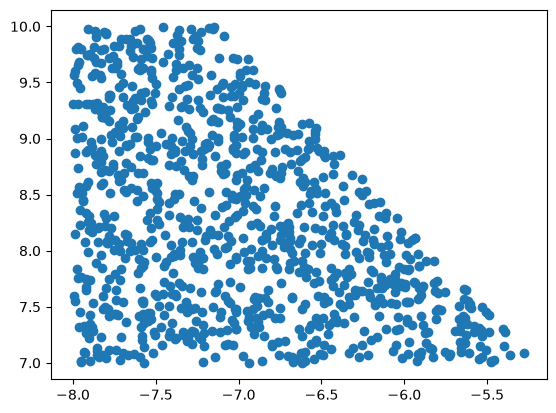

In [10]:
plt.scatter(*test_log_params.T)

In [11]:
roq_wf_dict

{(<Quantity 1.e-08 Hz>,
  <Quantity 8.94535738e-07 Hz>): <function isidora.training.rb_reconstructed_wf_factory.<locals>.exact_eim_reconst(t_, param)>,
 (<Quantity 8.94535738e-07 Hz>,
  <Quantity 1.77336479e-06 Hz>): <function isidora.training.rb_reconstructed_wf_factory.<locals>.exact_eim_reconst(t_, param)>,
 (<Quantity 1.77336479e-06 Hz>,
  <Quantity 2.65219385e-06 Hz>): <function isidora.training.rb_reconstructed_wf_factory.<locals>.exact_eim_reconst(t_, param)>,
 (<Quantity 2.65219385e-06 Hz>,
  <Quantity 3.5310229e-06 Hz>): <function isidora.training.rb_reconstructed_wf_factory.<locals>.exact_eim_reconst(t_, param)>,
 (<Quantity 3.5310229e-06 Hz>,
  <Quantity 4.40985196e-06 Hz>): <function isidora.training.rb_reconstructed_wf_factory.<locals>.exact_eim_reconst(t_, param)>,
 (<Quantity 4.40985196e-06 Hz>,
  <Quantity 5.28868102e-06 Hz>): <function isidora.training.rb_reconstructed_wf_factory.<locals>.exact_eim_reconst(t_, param)>,
 (<Quantity 5.28868102e-06 Hz>,
  <Quantity 6.1732

# Prepare EIM weights and sampled times

Need to downsample the EIM vectors to match downsampled time.

In [12]:
downsamp_eim_dict = {}

    # eim = tile_rb.basis.eim_
    # def exact_eim_reconst(t_, param):
    #     h_at_nodes = exact_het_eval_func(t_[eim.nodes], param)
    #     eim_reconst = (eim.interpolant @ np.array(h_at_nodes)) * reference_wf(t_)
    #     return eim_reconst

for freq_lim, rb in tile_rb_dict.items():
    eim = rb.basis.eim_
    print(eim.interpolant.shape)
    downsamp_eim_interp_vecs = eim.interpolant[downsample_mask]
    # These are not necessarily in downsampled_time! But they don't have to be.
    eval_times = full_time[eim.nodes]
    downsamp_eim_dict[freq_lim] = (eval_times, downsamp_eim_interp_vecs)

(61362, 229)
(61362, 291)
(61362, 322)
(61362, 359)
(61362, 400)
(61362, 425)
(61362, 409)


# Waveform-data inner products

Should be nearly trivial.

NB: we're not comparing between exact and ROQ here (this is done in paper, see 'Toy MCMC' notebooks), but between actually computing ROQ weights then inner prod using those weights, vs. the slight cheat of brute-forcing the inner prod but using the RB+EIM reconstructed waveform.

In [13]:
invcov_ip = lambda a, b: jnp.einsum('i,ij,j', a, invcov, b)

data_wf_ip = jax.jit(lambda wf: invcov_ip(mock_data, wf))

In [14]:
h_data_roq_weights = {}

for freq_lim, (eval_times, eim_basis) in downsamp_eim_dict.items():
    h_data_roq_weights[freq_lim] = (eval_times, jax.vmap(data_wf_ip)(eim_basis.T))

In [15]:
h_data_all_sparse_roq_ips = []

for test_p in test_log_params:
    # For dispatch dict.
    freq = 10**test_p[0]
    
    roq_alltime_ip = data_wf_ip(np.real(roq_wf_func_alltimes(test_p)))
    for (lf, hf), (eval_times, roq_weights) in h_data_roq_weights.items():
        if lf <= freq * u.Hz < hf:
            roq_ip = np.sum(np.real(exact_wf_func(eval_times, test_p) @ roq_weights))
            break
    h_data_all_sparse_roq_ips.append((roq_alltime_ip, roq_ip))

h_data_all_sparse_roq_ips = np.array(h_data_all_sparse_roq_ips)

(array([768., 187.,  30.,   7.,   1.,   2.,   0.,   1.,   2.,   2.]),
 array([0.00000000e+00, 5.05151476e-15, 1.01030295e-14, 1.51545443e-14,
        2.02060590e-14, 2.52575738e-14, 3.03090886e-14, 3.53606033e-14,
        4.04121181e-14, 4.54636329e-14, 5.05151476e-14]),
 <BarContainer object of 10 artists>)

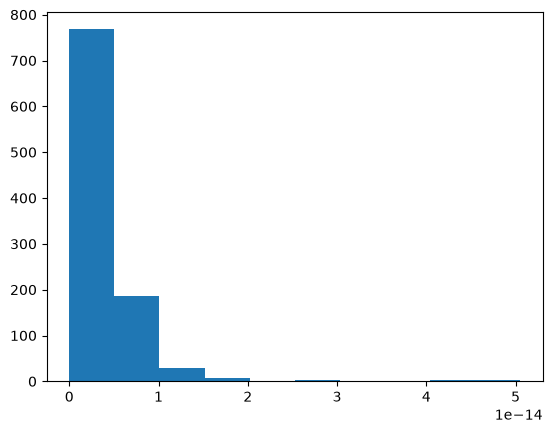

In [18]:
# Looks like floating-point order-of-op error to me.
plt.hist(np.abs(h_data_all_sparse_roq_ips[:, 0] - h_data_all_sparse_roq_ips[:, 1]))

# Waveform-waveform inner products

This is the trickier bit. Working with the complex RB+EIM waveform, we have to precompute
two sets of weights now: h* C^-1 h, and h C^-1 h. We can form the inner prod out of these and their conjugates.

In [19]:
# Each of these is a whole matrix.
h_h_roq_weights = {}

# only ij are the time dimensions, indices a and b are EIM basis index.
hh_invcov_ip = jax.jit(lambda v, w: jnp.einsum('ai,ij,bj->ab', v, invcov, w))

for freq_lim, (eval_times, eim_basis) in downsamp_eim_dict.items():
    h_h_roq_weights[freq_lim] = (eval_times, 
                                 hh_invcov_ip(eim_basis.T, eim_basis.T), 
                                 hh_invcov_ip(eim_basis.T.conj(), eim_basis.T))

In [32]:
h_h_all_sparse_roq_ips = []

roq_mat_ip = jax.jit(lambda v, m, w: jnp.einsum('a,ab,b', v, m, w))

for test_p in test_log_params:
    # For dispatch dict.
    freq = 10**test_p[0]

    roq_wf_alltimes = np.real(roq_wf_func_alltimes(test_p))
    
    roq_alltime_ip = invcov_ip(roq_wf_alltimes, roq_wf_alltimes)
    for (lf, hf), (eval_times, roq_mat_hh, roq_mat_hhconj) in h_h_roq_weights.items():
        if lf <= freq * u.Hz < hf:
            # NB: these are complex.
            roq_coeffs = exact_wf_func(eval_times, test_p)
            half_ip = roq_mat_ip(roq_coeffs, roq_mat_hh, roq_coeffs)
            half_ip += roq_mat_ip(roq_coeffs.conj(), roq_mat_hhconj, roq_coeffs)
            # Just realized this is kind of dumb, I could just do np.real(half_ip).
            # Pretty sure both weight matrices are still needed though.
            roq_ip = 0.25 * (half_ip + half_ip.conj())
            break
    h_h_all_sparse_roq_ips.append((roq_alltime_ip, roq_ip))

h_h_all_sparse_roq_ips = np.array(h_h_all_sparse_roq_ips)

In [33]:
h_h_all_sparse_roq_ips

array([[0.01641174+0.j, 0.01641174+0.j],
       [0.04001069+0.j, 0.04001069+0.j],
       [0.12181792+0.j, 0.12181792+0.j],
       ...,
       [0.01042159+0.j, 0.01042159+0.j],
       [0.12406132+0.j, 0.12406132+0.j],
       [0.02204614+0.j, 0.02204614+0.j]], shape=(1000, 2))

In [37]:
assert (np.imag(h_h_all_sparse_roq_ips) == 0).all()

(array([882.,  81.,  24.,   7.,   3.,   0.,   0.,   1.,   1.,   1.]),
 array([0.00000000e+00, 2.58126853e-16, 5.16253706e-16, 7.74380560e-16,
        1.03250741e-15, 1.29063427e-15, 1.54876112e-15, 1.80688797e-15,
        2.06501483e-15, 2.32314168e-15, 2.58126853e-15]),
 <BarContainer object of 10 artists>)

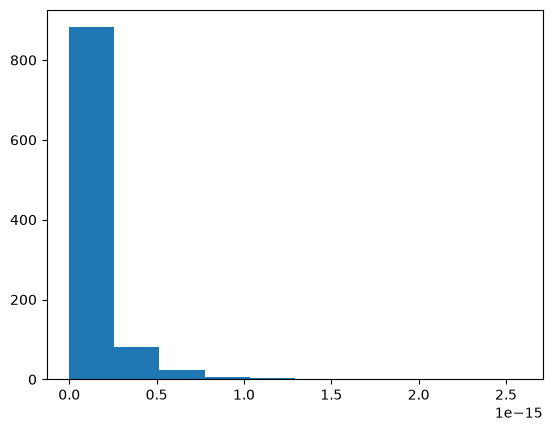

In [38]:
# Cool.
plt.hist(np.abs(h_h_all_sparse_roq_ips[:, 0] - h_h_all_sparse_roq_ips[:, 1]))